# Deutschlandkurier — Cleaning, EDA, and BERTopic Run

Outlet-specific notebook for **Deutschlandkurier**. Loads the raw Deutschlandkurier exports, applies the outlet-specific cleaning rules (boilerplate removal, deduplication, length filter), runs descriptive EDA on the cleaned corpus, and fits an individual BERTopic model using the shared three-stage pipeline (SBERT → UMAP → HDBSCAN, c-TF-IDF representation) from `../01_BERTopic_configuration/`. The saved model and topic table feed the merge step in `../../02_TopicModeling/`.

In [1]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Deutschlandkurier"
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
df.head()


Loaded 1977 rows from 222 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Deutschlandkurier


,id,title,teaser,categories,lastModified,created,publishedAt,authors,url,article_text,source,source_file
0,92655,Autokrise: Auch BMW-Gewinne brechen massiv ein!,Die Horrormeldungen aus der Automobilbranche r...,Wirtschaft,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,2025-07-31T08:50:16+00:00,NaN,https://deutschlandkurier.de/2025/07/autokrise...,Die Horrormeldungen aus der Automobilbranche r...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
1,92658,Verfassungsrichter: Top-Staatsrechtler Rupert ...,Vor dem Hintergrund des aktuellen Streits um d...,Politik,2025-07-31T11:59:26+00:00,2025-07-31T09:16:48+00:00,2025-07-31T09:16:48+00:00,NaN,https://deutschlandkurier.de/2025/07/verfassun...,Vor dem Hintergrund des aktuellen Streits um d...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
2,92666,„Nazi-Codes!“ Woker Aufstand im Netz gegen Syd...,Die US-amerikanische Schauspielerin Sydney Swe...,Ausland,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,2025-07-31T11:09:19+00:00,NaN,https://deutschlandkurier.de/2025/07/nazi-code...,Die US-amerikanische Schauspielerin Sydney Swe...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
3,92669,SPD löscht Wut-Attacke auf Union aus Online-Ka...,In einer Online-Kampagne hat die SPD ihren Koa...,Politik,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,2025-07-31T11:46:15+00:00,NaN,https://deutschlandkurier.de/2025/07/spd-loesc...,In einer Online-Kampagne hat die SPD ihren Koa...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv
4,92672,Bürgermeister von Hiddensee schreibt Alarm-Bri...,Der Bürgermeister der 1.000 Einwohner zählende...,Politik,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,2025-07-31T11:48:25+00:00,NaN,https://deutschlandkurier.de/2025/07/buergerme...,Der Bürgermeister der 1.000 Einwohner zählende...,Deutschlandkurier,deutschlandkurier_articles_2025-07-31.csv


In [2]:
df_cleaned = df[['title', 'categories', 'created', 'article_text', 'url', 'source']].copy()
df_cleaned.columns = ['Title', 'categories', 'Date', 'Text', 'URL', 'source']

In [3]:
# Check duplicates and NaNs in Title/Text columns using df_cleaned
title_col = "Title" if "Title" in df_cleaned.columns else "title" if "title" in df_cleaned.columns else None
text_col = "Text" if "Text" in df_cleaned.columns else "text" if "text" in df_cleaned.columns else "article_text" if "article_text" in df_cleaned.columns else None

if title_col is None or text_col is None:
    raise KeyError(f"Could not find title/text columns in df_cleaned. Available columns: {list(df_cleaned.columns)}")

check_cols = [title_col, text_col]

# NaN counts
nan_counts = df_cleaned[check_cols].isna().sum()

# Duplicate counts (excluding NaN values)
dup_title_count = df_cleaned[title_col].dropna().duplicated().sum()
dup_text_count = df_cleaned[text_col].dropna().duplicated().sum()
dup_title_text_pair_count = df_cleaned[check_cols].dropna().duplicated().sum()

print("NaN counts:")
print(nan_counts)
print("\nDuplicate counts:")
print(f"Duplicate {title_col}: {dup_title_count}")
print(f"Duplicate {text_col}: {dup_text_count}")
print(f"Duplicate ({title_col}, {text_col}) pairs: {dup_title_text_pair_count}")

# Optional: preview duplicate rows by title+text
duplicate_rows = df_cleaned[df_cleaned.duplicated(subset=check_cols, keep=False)].sort_values(check_cols)
print(f"\nRows involved in duplicated ({title_col}, {text_col}) pairs: {len(duplicate_rows)}")
duplicate_rows.head(10)

NaN counts:
Title     38
Text     154
dtype: int64

Duplicate counts:
Duplicate Title: 7
Duplicate Text: 9
Duplicate (Title, Text) pairs: 1

Rows involved in duplicated (Title, Text) pairs: 40


,Title,categories,Date,Text,URL,source
1947,Gewinner – Verlierer der Woche,Gewinner und Verlierer der Woche,2026-03-07T09:08:02+00:00,Gewinner der Woche\n\nDie 10. Klasse des Oster...,https://deutschlandkurier.de/2026/03/gewinner-...,Deutschlandkurier
1958,Gewinner – Verlierer der Woche,Mehr,2026-03-07T20:26:52+00:00,Gewinner der Woche\n\nDie 10. Klasse des Oster...,https://deutschlandkurier.de/2026/03/gewinner-...,Deutschlandkurier
110,NaN,AfD,2025-08-13T10:39:03+00:00,NaN,https://deutschlandkurier.de/2025/08/93109/,Deutschlandkurier
111,NaN,AfD,2025-08-13T11:55:59+00:00,NaN,https://deutschlandkurier.de/2025/08/93114/,Deutschlandkurier
113,NaN,AfD,2025-08-13T12:20:10+00:00,NaN,https://deutschlandkurier.de/2025/08/93125/,Deutschlandkurier
114,NaN,AfD,2025-08-13T13:17:50+00:00,NaN,https://deutschlandkurier.de/2025/08/93128/,Deutschlandkurier
122,NaN,AfD,2025-08-14T10:21:14+00:00,NaN,https://deutschlandkurier.de/2025/08/93159/,Deutschlandkurier
213,NaN,AfD,2025-08-24T12:10:40+00:00,NaN,https://deutschlandkurier.de/2025/08/93532/,Deutschlandkurier
228,NaN,AfD,2025-08-25T14:17:49+00:00,NaN,https://deutschlandkurier.de/2025/08/93589/,Deutschlandkurier
244,NaN,AfD,2025-08-27T09:17:07+00:00,NaN,https://deutschlandkurier.de/2025/08/93652/,Deutschlandkurier


In [4]:
# Remove rows with NaN in text column and drop duplicate title+text pairs (on df_cleaned only)
rows_before = len(df_cleaned)

nan_text_removed = df_cleaned[text_col].isna().sum()
df_cleaned = df_cleaned[df_cleaned[text_col].notna()].copy()

dup_removed = df_cleaned.duplicated(subset=check_cols, keep="first").sum()
df_cleaned = df_cleaned.drop_duplicates(subset=check_cols, keep="first").copy()

rows_after = len(df_cleaned)
print(f"Removed {nan_text_removed} rows with NaN in '{text_col}'.")
print(f"Removed {dup_removed} duplicate rows based on {check_cols}.")
print(f"Rows before: {rows_before} | Rows after: {rows_after}")


Removed 154 rows with NaN in 'Text'.
Removed 1 duplicate rows based on ['Title', 'Text'].
Rows before: 1977 | Rows after: 1822


In [5]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 1822 entries, 0 to 1976
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       1822 non-null   object
 1   categories  1822 non-null   object
 2   Date        1822 non-null   object
 3   Text        1822 non-null   object
 4   URL         1822 non-null   object
 5   source      1822 non-null   str   
dtypes: object(5), str(1)
memory usage: 99.6+ KB


In [6]:
# Convert Date to datetime dtype
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors="coerce")



In [7]:
df_cleaned['Date'].min()

Timestamp('2025-07-31 08:50:16+0000', tz='UTC')

In [8]:
# keep Date as real datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")

# optional: remove timezone + keep only date (00:00:00 time)
df_cleaned["Date"] = df_cleaned["Date"].dt.tz_convert(None).dt.normalize()

# correct chronological min/max
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())


2025-07-31 00:00:00 2026-03-09 00:00:00


In [9]:
# df_cleaned["Date"] = (
#     pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
#       .dt.tz_convert(None)
#       .dt.normalize()
# )

# print(df_cleaned["Date"].dtype)   # datetime64[ns]


In [10]:
df_cleaned["Date"] = (
    pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
      .dt.tz_convert(None)
      .dt.date
)


In [11]:
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())

2025-07-31 2026-03-09


In [12]:
# Filter df_cleaned to 01.08.2025 - 31.01.2026 (inclusive)
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"], errors="coerce")
df_cleaned = df_cleaned.loc[
    (df_cleaned["Date"] >= "2025-08-01") & (df_cleaned["Date"] <= "2026-01-31")
].copy()

print(f"Rows after date filter: {len(df_cleaned)}")
print("Date range:", df_cleaned["Date"].min(), "->", df_cleaned["Date"].max())


Rows after date filter: 1484
Date range: 2025-08-01 00:00:00 -> 2026-01-31 00:00:00


In [13]:
df_cleaned["Date"] = (
    pd.to_datetime(df_cleaned["Date"], utc=True, errors="coerce")
      .dt.tz_convert(None)
      .dt.date
)


In [14]:
print(df_cleaned["Date"].min(), df_cleaned["Date"].max())

2025-08-01 2026-01-31


## EDA

In [15]:
# Short EDA prep based on df_cleaned
eda_df = df_cleaned.copy()

if "Text" not in eda_df.columns:
    raise KeyError("Spalte 'Text' nicht gefunden in df_cleaned.")
if "Date" not in eda_df.columns:
    raise KeyError("Spalte 'Date' nicht gefunden in df_cleaned.")

eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")
eda_df["Date"] = eda_df["Date"].dt.strftime("%Y.%m.%d")

eda_df["article_length_words"] = eda_df["Text"].astype("string").str.split().str.len()

eda_df[["Date", "article_length_words"]].head()


,Date,article_length_words
9,2025.08.01,100
10,2025.08.01,110
11,2025.08.01,336
12,2025.08.01,219
13,2025.08.01,47


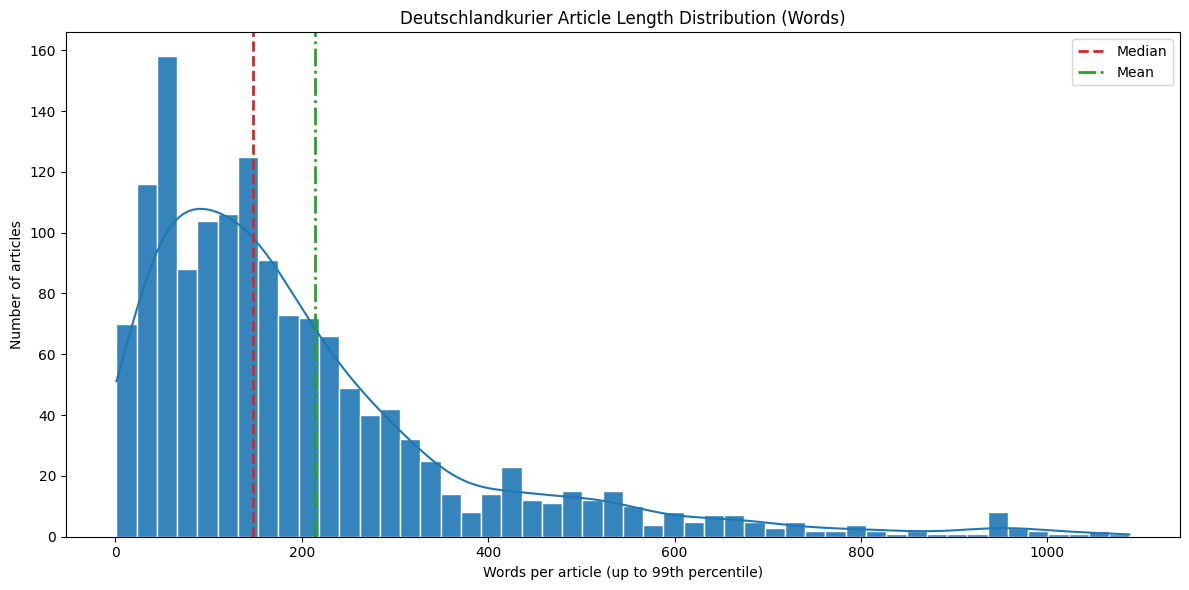

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Deutschlandkurier Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()


Save cleaned table for further analysis

In [17]:
dkurier_clean = df_cleaned[["Date", "Title", "Text", "source"]].copy()
dkurier_clean.to_csv("dkurier_clean.csv", index=False, encoding="utf-8")
print(f"Saved cleaned Deutschlandkurier corpus: {len(dkurier_clean):,} rows")

Saved cleaned Deutschlandkurier corpus: 1,484 rows


## BERTopic

In [18]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

project_root = resolve_project_root()
module_root = project_root / "02_TopicModeling"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))

In [19]:
from bertopic_pipeline import run_bertopic_pipeline


In [20]:
from bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [21]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "02_TopicModeling").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 02_TopicModeling")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "02_TopicModeling"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)


cwd: /Users/MattisHaumann/Dev/Thesis/01_EDAperOutlet
project root added: /Users/MattisHaumann/Dev/Thesis
bertopic module root added: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling


In [22]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "01_EDAperOutlet" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_cleaned = (
    df_combined.loc[df_combined["source"].eq("Deutschlandkurier")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Deutschlandkurier subset from df_combined: {len(df_cleaned):,} rows")


Loaded canonical Deutschlandkurier subset from df_combined: 1,484 rows


In [23]:
# Canonical final Deutschlandkurier run.
# This notebook keeps the standard full-text BERTopic configuration on the cleaned DK corpus.
# The final saved model is the reduced model below after c-TF-IDF outlier reduction with threshold=0.10.
result_full_text = run_bertopic_pipeline(
    df=df_cleaned,
    text_col="Text",
    config=BERTopicConfig(hdbscan_min_cluster_size=14),  # lowered from default 20; more granular topics for 1,465-doc corpus
    id_col="row_id",
    source_name="Deutschlandkurier",
)

# Keep downstream notebook cells unchanged while also mirroring the outlet-specific naming pattern.
result_dk = result_full_text
result = result_dk


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:04:58,007 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2026-03-31 21:05:09,258 - BERTopic - Embedding - Completed ✓
2026-03-31 21:05:09,259 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:05:27,742 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:05:27,747 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:05:27,808 - BERTopic - Cluster - Completed ✓
2026-03-31 21:05:27,821 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:05:29,132 - BERTopic - Representation - Completed ✓


In [24]:
topic_info_dkurier = result_dk["topic_info"]
topic_info_dkurier.head(30)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,474,-1_euro_csu_man_weimer,"[euro, csu, man, weimer, spd, wurde, 000, us, ...",[Der neue Jugendverband der Alternative für De...
1,0,154,0_bendels_faeser_meinungsfreiheit_david,"[bendels, faeser, meinungsfreiheit, david, dav...",[Der vom Deutschland-Kurier (DK) mit aller Ent...
2,1,119,1_trump_us_ukraine_putin,"[trump, us, ukraine, putin, präsident, selensk...",[Nach Alaska schaut die Welt jetzt gebannt auf...
3,2,87,2_afghanen_migranten_000_asyl,"[afghanen, migranten, 000, asyl, personen, eu,...",[Laut dem Innenministerium in Teheran müssen b...
4,3,84,3_klima_energiewende_co₂_gas,"[klima, energiewende, co₂, gas, studie, strom,...",[Große Klimasause mit Kanzler Friedrich Merz (...
5,4,75,4_euro_milliarden_milliarden euro_millionen,"[euro, milliarden, milliarden euro, millionen,...",[Der Haushaltsausschuss des Deutschen Bundesta...
6,5,69,5_kanzler_friedrich_friedrich merz_koalition,"[kanzler, friedrich, friedrich merz, koalition...",[Nach seinem Renten-Pakt mit den Nachfolgern d...
7,6,57,6_industrie_unternehmen_000_zahl,"[industrie, unternehmen, 000, zahl, millionen,...",[Alle zarten Hoffnungen auf eine langsame Erho...
8,7,51,7_gießen_antifa_rechts_linksextremisten,"[gießen, antifa, rechts, linksextremisten, dem...",[Es war die bisher größte rechts-patriotische ...
9,8,41,8_polizei_syrer_festgenommen_wurde,"[polizei, syrer, festgenommen, wurde, messer, ...",[Unter dem öffentlichen Fahndungsdruck hat sic...


### Outlier Reduction (focused section)

This section starts from the selected Deutschlandkurier topic model (`result_dk`) and mirrors the same final reduced-model workflow used in the other outlet notebooks.

> **Final downstream workflow:** use the canonical final Deutschlandkurier fit above, then apply `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`.


In [25]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_dk).
base_result = result_dk
topic_model_base = base_result["topic_model"]
docs_dk = list(base_result["docs"])
topics_dk = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_dk if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_dk,
    topics_dk,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_dk,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=topic_model_base.top_n_words,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_dk_reduced = dict(base_result)
result_dk_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_dk_reduced["topic_model"] = topic_model_ctfidf_threshold
result_dk_reduced["topic_info"] = topic_info_ctfidf_threshold
result_dk_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_dk_reduced["doc_info"] = doc_info_reduced
result_dk_reduced["display_topic_map"] = display_topic_map
result_dk_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_dk) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))


2026-03-31 21:05:32,410 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,474,18
1,ctfidf_threshold_0.10,174,18


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_kommission_kurier_deutschland kurier_baerbock,-1,174,-1_kommission_kurier_deutschland kurier_baerbock,"[kommission, kurier, deutschland kurier, baerb...",[Der neue Jugendverband der Alternative für De...
1,0,1,Topic 1 — faeser_bendels_meinungsfreiheit_david,faeser_bendels_meinungsfreiheit_david,0,188,0_faeser_bendels_meinungsfreiheit_david,"[faeser, bendels, meinungsfreiheit, david, dav...",[Der vom Deutschland-Kurier (DK) mit aller Ent...
2,1,2,Topic 2 — trump_us_ukraine_präsident,trump_us_ukraine_präsident,1,162,1_trump_us_ukraine_präsident,"[trump, us, ukraine, präsident, selenskyj, put...",[Nach Alaska schaut die Welt jetzt gebannt auf...
3,2,5,Topic 5 — afghanen_migranten_personen_asyl,afghanen_migranten_personen_asyl,2,95,2_afghanen_migranten_personen_asyl,"[afghanen, migranten, personen, asyl, eu, bund...",[Laut dem Innenministerium in Teheran müssen b...
4,3,6,Topic 6 — klima_energiewende_gas_co₂,klima_energiewende_gas_co₂,3,87,3_klima_energiewende_gas_co₂,"[klima, energiewende, gas, co₂, studie, strom,...",[Große Klimasause mit Kanzler Friedrich Merz (...
5,4,4,Topic 4 — euro_milliarden_milliarden euro_mill...,euro_milliarden_milliarden euro_millionen,4,102,4_euro_milliarden_milliarden euro_millionen,"[euro, milliarden, milliarden euro, millionen,...",[Der Haushaltsausschuss des Deutschen Bundesta...
6,5,3,Topic 3 — kanzler_weimer_spd_söder,kanzler_weimer_spd_söder,5,115,5_kanzler_weimer_spd_söder,"[kanzler, weimer, spd, söder, koalition, merz ...",[Nach seinem Renten-Pakt mit den Nachfolgern d...
7,6,9,Topic 9 — industrie_unternehmen_zahl_wirtschaft,industrie_unternehmen_zahl_wirtschaft,6,64,6_industrie_unternehmen_zahl_wirtschaft,"[industrie, unternehmen, zahl, wirtschaft, mil...",[Alle zarten Hoffnungen auf eine langsame Erho...
8,7,8,Topic 8 — gießen_antifa_generation_generation ...,gießen_antifa_generation_generation deutschland,7,68,7_gießen_antifa_generation_generation deutschland,"[gießen, antifa, generation, generation deutsc...",[Es war die bisher größte rechts-patriotische ...
9,8,10,Topic 10 — polizei_messer_syrer_festgenommen,polizei_messer_syrer_festgenommen,8,49,8_polizei_messer_syrer_festgenommen,"[polizei, messer, syrer, festgenommen, jährige...",[Unter dem öffentlichen Fahndungsdruck hat sic...


In [26]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and save the canonical final Deutschlandkurier model to outputs/.
result_dk = result_dk_reduced
result = result_dk
topic_info = result_dk["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())
save_dir = project_root / "02_TopicModeling" / "outputs" / "dk_model"
save_dir.parent.mkdir(parents=True, exist_ok=True)
if save_dir.exists():
    shutil.rmtree(save_dir)

topic_model_ctfidf_threshold.save(
    save_dir,
    serialization="safetensors",
    save_ctfidf=True,
    save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

print(f"Saved final reduced model to: {save_dir}")


Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/02_TopicModeling/outputs/dk_model


In [27]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_dk_reduced if "result_dk_reduced" in globals() else result_dk
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_kommission_kurier_deutschland kurier_baerbock,-1,174,-1_kommission_kurier_deutschland kurier_baerbock,"[kommission, kurier, deutschland kurier, baerb...",[Der neue Jugendverband der Alternative für De...
1,0,1,Topic 1 — faeser_bendels_meinungsfreiheit_david,faeser_bendels_meinungsfreiheit_david,0,188,0_faeser_bendels_meinungsfreiheit_david,"[faeser, bendels, meinungsfreiheit, david, dav...",[Der vom Deutschland-Kurier (DK) mit aller Ent...
2,1,2,Topic 2 — trump_us_ukraine_präsident,trump_us_ukraine_präsident,1,162,1_trump_us_ukraine_präsident,"[trump, us, ukraine, präsident, selenskyj, put...",[Nach Alaska schaut die Welt jetzt gebannt auf...
3,2,5,Topic 5 — afghanen_migranten_personen_asyl,afghanen_migranten_personen_asyl,2,95,2_afghanen_migranten_personen_asyl,"[afghanen, migranten, personen, asyl, eu, bund...",[Laut dem Innenministerium in Teheran müssen b...
4,3,6,Topic 6 — klima_energiewende_gas_co₂,klima_energiewende_gas_co₂,3,87,3_klima_energiewende_gas_co₂,"[klima, energiewende, gas, co₂, studie, strom,...",[Große Klimasause mit Kanzler Friedrich Merz (...
5,4,4,Topic 4 — euro_milliarden_milliarden euro_mill...,euro_milliarden_milliarden euro_millionen,4,102,4_euro_milliarden_milliarden euro_millionen,"[euro, milliarden, milliarden euro, millionen,...",[Der Haushaltsausschuss des Deutschen Bundesta...
6,5,3,Topic 3 — kanzler_weimer_spd_söder,kanzler_weimer_spd_söder,5,115,5_kanzler_weimer_spd_söder,"[kanzler, weimer, spd, söder, koalition, merz ...",[Nach seinem Renten-Pakt mit den Nachfolgern d...
7,6,9,Topic 9 — industrie_unternehmen_zahl_wirtschaft,industrie_unternehmen_zahl_wirtschaft,6,64,6_industrie_unternehmen_zahl_wirtschaft,"[industrie, unternehmen, zahl, wirtschaft, mil...",[Alle zarten Hoffnungen auf eine langsame Erho...
8,7,8,Topic 8 — gießen_antifa_generation_generation ...,gießen_antifa_generation_generation deutschland,7,68,7_gießen_antifa_generation_generation deutschland,"[gießen, antifa, generation, generation deutsc...",[Es war die bisher größte rechts-patriotische ...
9,8,10,Topic 10 — polizei_messer_syrer_festgenommen,polizei_messer_syrer_festgenommen,8,49,8_polizei_messer_syrer_festgenommen,"[polizei, messer, syrer, festgenommen, jährige...",[Unter dem öffentlichen Fahndungsdruck hat sic...


### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


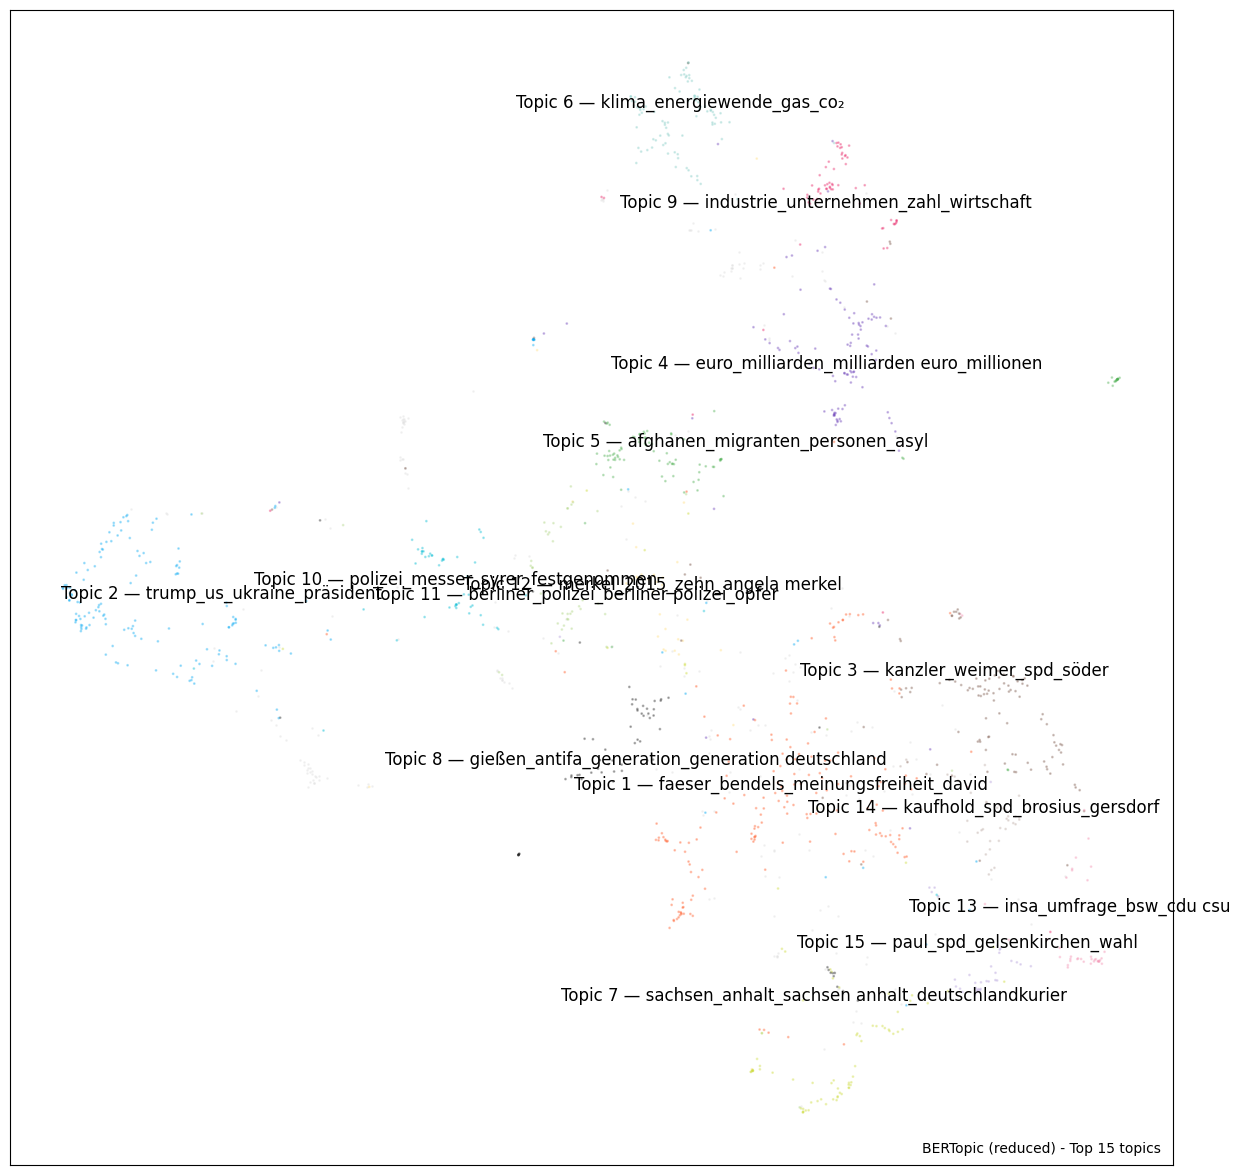

In [28]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_dk_reduced if "result_dk_reduced" in globals() else result_dk
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()


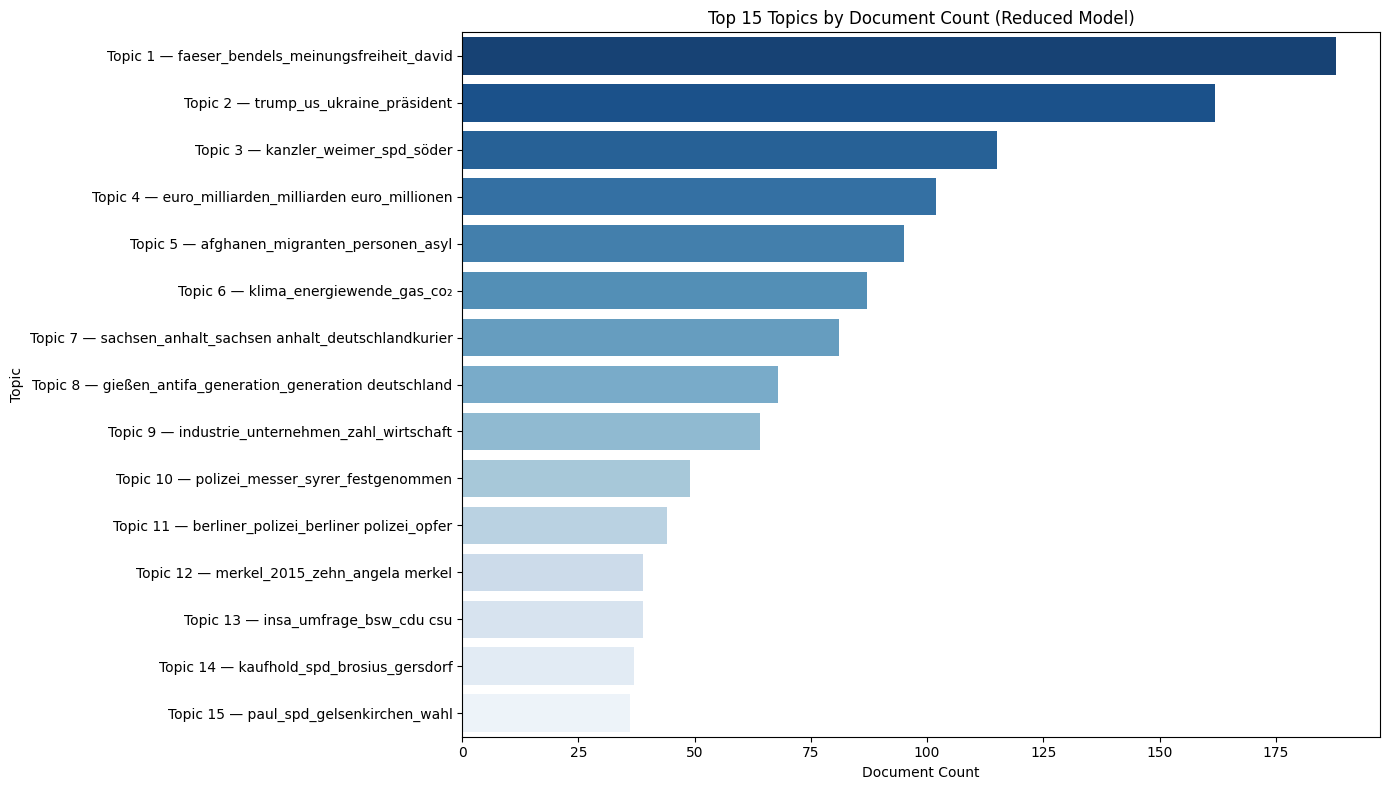

In [29]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Final top-15 bar chart on the reduced model with unified topic numbering.
run_result = result_dk_reduced if "result_dk_reduced" in globals() else result_dk
topic_info_run = run_result["topic_info"].copy()

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()


## Topics Over Time

Uses `result_dk_reduced` if you have already run the outlier-reduction cell; otherwise it falls back to the selected baseline `result_dk`.


6it [00:04,  1.43it/s]


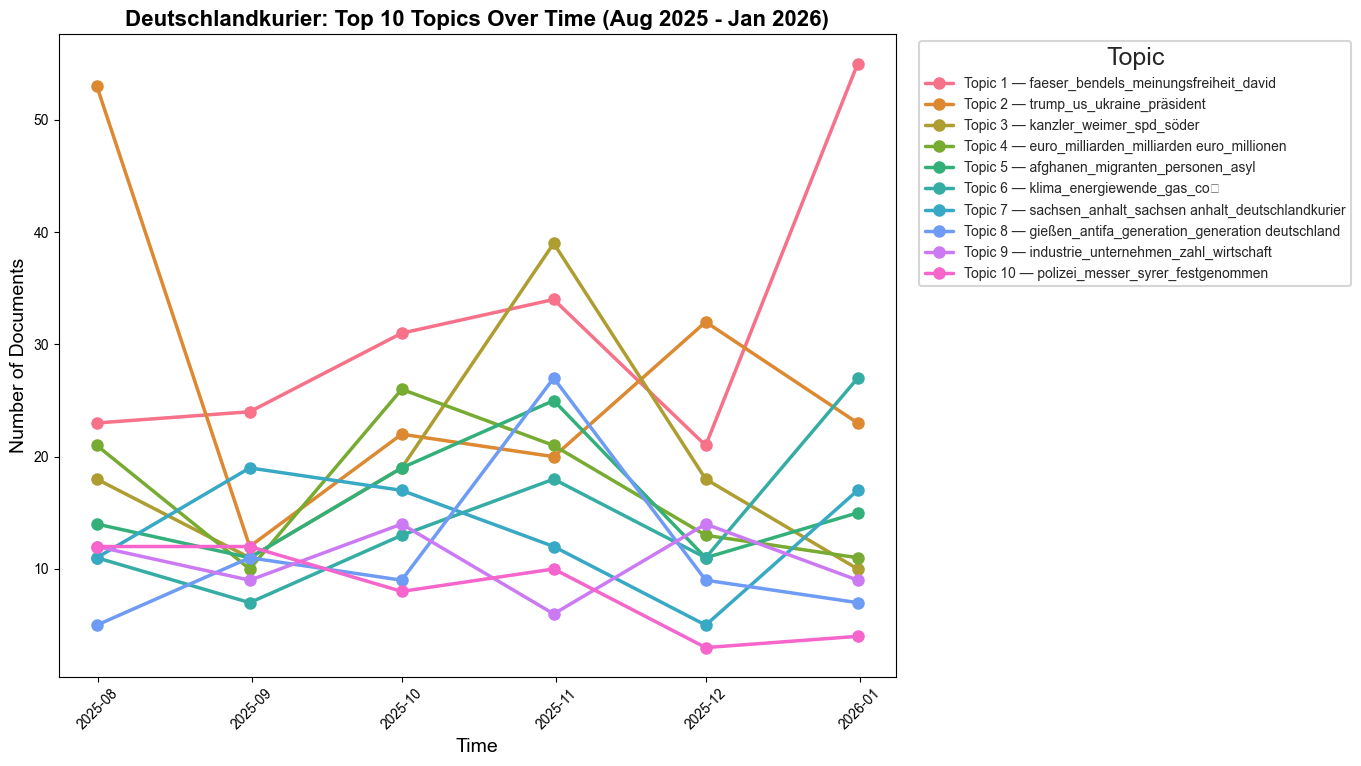

In [30]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_dk_reduced`.
topic_time_result = result_dk_reduced if "result_dk_reduced" in globals() else result_dk

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Deutschlandkurier: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
